In [2]:
import os

# Create a directory for Kaggle and copy the API key there
!mkdir -p ~/.kaggle
# Corrected path to kaggle.json assuming it's in the default Colab Drive mount path
!cp "/content/drive/MyDrive/kaggle.json" ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download the dataset (replace 'ahmedhamada0/brain-tumor-detection' with the correct dataset slug)
!kaggle datasets download -d ahmedhamada0/brain-tumor-detection

# Unzip the dataset
!unzip brain-tumor-detection.zip -d /content/

Dataset URL: https://www.kaggle.com/datasets/ahmedhamada0/brain-tumor-detection
License(s): copyright-authors
  0% 0.00/84.0M [00:00<?, ?B/s]
100% 84.0M/84.0M [00:00<00:00, 1.73GB/s]
Archive:  brain-tumor-detection.zip
  inflating: /content/Br35H-Mask-RCNN/TEST/annotations_test.json  
  inflating: /content/Br35H-Mask-RCNN/TEST/y701.jpg  
  inflating: /content/Br35H-Mask-RCNN/TEST/y702.jpg  
  inflating: /content/Br35H-Mask-RCNN/TEST/y703.jpg  
  inflating: /content/Br35H-Mask-RCNN/TEST/y704.jpg  
  inflating: /content/Br35H-Mask-RCNN/TEST/y705.jpg  
  inflating: /content/Br35H-Mask-RCNN/TEST/y706.jpg  
  inflating: /content/Br35H-Mask-RCNN/TEST/y707.jpg  
  inflating: /content/Br35H-Mask-RCNN/TEST/y708.jpg  
  inflating: /content/Br35H-Mask-RCNN/TEST/y709.jpg  
  inflating: /content/Br35H-Mask-RCNN/TEST/y710.jpg  
  inflating: /content/Br35H-Mask-RCNN/TEST/y711.jpg  
  inflating: /content/Br35H-Mask-RCNN/TEST/y712.jpg  
  inflating: /content/Br35H-Mask-RCNN/TEST/y713.jpg  
  inflating:

**Reasoning**:
The previous attempt to load images using `flow_from_directory` incorrectly identified all top-level directories as classes. I need to modify the code to explicitly include only the 'yes' and 'no' directories as the target classes for the binary classification task. Removed 'workers' and 'use_multiprocessing' arguments as they are not supported in this TensorFlow/Keras version. Also modified the code to copy `kaggle.json` from Google Drive for persistence.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install kaggle

Found 2400 images belonging to 2 classes.
Found 600 images belonging to 2 classes.
Class labels: {'yes': 0, 'no': 1}


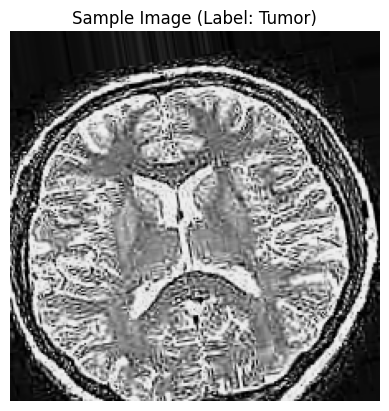

In [4]:
import os
import cv2
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# Define paths
# Corrected path to the main dataset directory containing 'yes' and 'no' folders
dataset_dir = '/content/' # Updated to the unzipped directory name

# Parameters
IMG_SIZE = (224, 224)  # Standard size for CNNs
BATCH_SIZE = 32

# 1. Data Augmentation (for training data, including brightness)
train_datagen = ImageDataGenerator(
    rescale=1./255,  # Normalization to [0,1]
    rotation_range=10,  # Random rotation ±10 degrees
    width_shift_range=0.1,  # Horizontal shift
    height_shift_range=0.1,  # Vertical shift
    shear_range=0.1,  # Shear transformation
    zoom_range=0.1,  # Random zoom
    horizontal_flip=True,  # Random horizontal flip
    brightness_range=[0.8, 1.2],  # Adjust brightness (80% to 120% of original)
    fill_mode='nearest',
    validation_split=0.2 # Split for validation
)

# 2. Load and preprocess images from directory
# Using flow_from_directory on the main dataset directory
train_generator = train_datagen.flow_from_directory(
    dataset_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',  # For 'yes'/'no' classification
    subset='training',  # Use training subset
    shuffle=True,
    classes=['yes', 'no'] # Explicitly specify the classes
    # color_mode='grayscale'  # Keep as color images for standard models
    # Removed workers=os.cpu_count(), # Add workers for potentially faster loading and better handling
    # Removed use_multiprocessing=True # Enable multiprocessing
)

# Validation generator using the same data generator but validation subset
val_generator = train_datagen.flow_from_directory(
    dataset_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',  # Use validation subset
    classes=['yes', 'no'] # Explicitly specify the classes
    # color_mode='grayscale' # Keep as color images
    # Removed workers=os.cpu_count(), # Add workers
    # Removed use_multiprocessing=True # Enable multiprocessing
)


# 4. Verify class labels
print("Class labels:", train_generator.class_indices)

# 5. Visualize a sample preprocessed image
sample_image, sample_label = next(train_generator)
# Adjust imshow for color images (remove .squeeze() if not grayscale)
plt.imshow(sample_image[0])
plt.title(f"Sample Image (Label: {'Tumor' if sample_label[0] == 1 else 'No Tumor'})")
plt.axis('off')
plt.show()

In [5]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# 1. Load the InceptionV3 model
# We load the pre-trained InceptionV3 model without the top classification layer
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

# Freeze the layers of the base model
for layer in base_model.layers:
    layer.trainable = False

# 2. Add new layers
# Add a Flatten layer
x = Flatten()(base_model.output)

# Add a Dense layer with ReLU activation
x = Dense(128, activation='relu')(x)

# Add a Dropout layer for regularization
x = Dropout(0.5)(x)

# Add the output layer for binary classification (sigmoid activation)
predictions = Dense(1, activation='sigmoid')(x)

# Create the new model
model = Model(inputs=base_model.input, outputs=predictions)

# 3. Compile the model
# Using the Adam optimizer and binary crossentropy loss for binary classification
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 111, 111,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 111, 111,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 111, 111,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 109, 109,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 109, 109,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 54, 54,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 54, 54,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 54,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 54, 54,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 52, 52,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 52, 52,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 52, 52,    │          0 │ batch_normalizat

 Total params: 28,356,641 (108.17 MB)

 Trainable params: 6,553,857 (25.00 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [6]:
# 4. Train the model
# Define the number of epochs
EPOCHS = 10 # You can adjust this number

# Train the model using the data generators
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=EPOCHS,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 72s 699ms/step - accuracy: 0.7083 - loss: 0.9203 - val_accuracy: 0.8767 - val_loss: 0.2989
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 62s 588ms/step - accuracy: 0.8856 - loss: 0.2872 - val_accuracy: 0.9219 - val_loss: 0.1936
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 45s 599ms/step - accuracy: 0.9025 - loss: 0.2341 - val_accuracy: 0.9462 - val_loss: 0.1519
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 44s 582ms/step - accuracy: 0.9120 - loss: 0.2146 - val_accuracy: 0.9549 - val_loss: 0.1251
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 44s 582ms/step - accuracy: 0.9285 - loss: 0.1821 - val_accuracy: 0.9531 - val_loss: 0.1343
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 44s 582ms/step - accuracy: 0.9324 - loss: 0.1762 - val_accuracy: 0.9549 - val_loss: 0.1315
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 45s 599ms/step - accuracy: 0.9449 - loss: 0.1439 - val_accuracy: 0.9427 - val_loss: 0.1351
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 44s 581ms/step - accuracy: 0.9304 - loss: 0.1896 - val_accu

19/19 ━━━━━━━━━━━━━━━━━━━━ 17s 884ms/step - accuracy: 0.9684 - loss: 0.0876
Validation Loss: 0.0923
Validation Accuracy: 0.9617


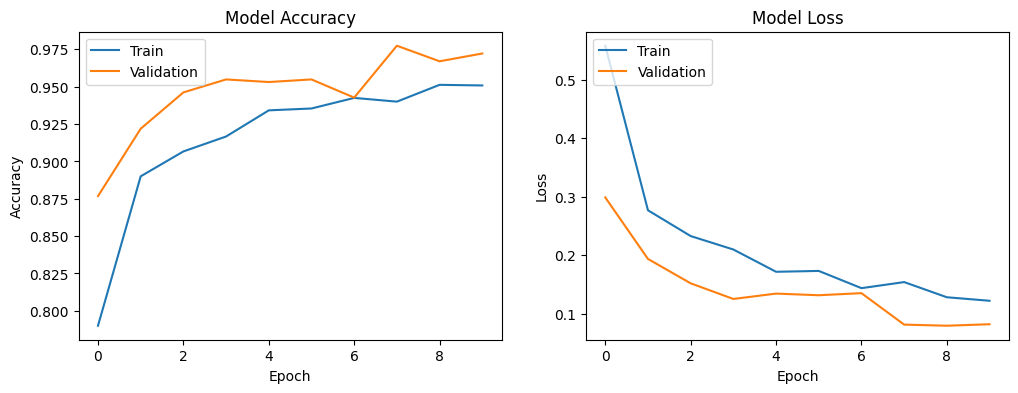

In [7]:
# 5. Evaluate the model
# Evaluate the model on the validation set
loss, accuracy = model.evaluate(val_generator)

print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

# Plot training and validation accuracy and loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
The model predicts: yes (0.0211)


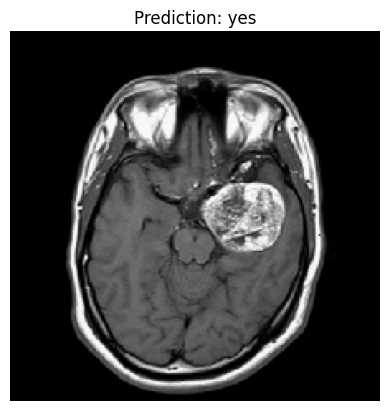

In [18]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Function to load and preprocess a new image
def preprocess_image(image_path, target_size):
    img = image.load_img(image_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array /= 255.0  # Rescale the image
    return img_array

# Specify the path to the new image you want to test
# You can replace this with the path to your uploaded MRI image
new_image_path = '/content/BRAIN-MRI-T1-weighted-sequence-with-temporal-lesion-well-delineated-heterogeneous.png' # Example image from the dataset

# Preprocess the new image
preprocessed_image = preprocess_image(new_image_path, IMG_SIZE)

# Make a prediction using the trained model
prediction = model.predict(preprocessed_image)

# Interpret the prediction based on train_generator.class_indices
# Assuming 'yes' is class 0 and 'no' is class 1 as per train_generator.class_indices
# If prediction probability is closer to 1, it belongs to class 1 ('no' tumor)
# If prediction probability is closer to 0, it belongs to class 0 ('yes' tumor)

predicted_class_index = 1 if prediction[0][0] > 0.5 else 0

# Get the class label from the index
class_labels = list(train_generator.class_indices.keys())
predicted_class = class_labels[predicted_class_index]


print(f"The model predicts: {predicted_class} ({prediction[0][0]:.4f})")


# Display the image with the prediction
img = image.load_img(new_image_path, target_size=IMG_SIZE)
plt.imshow(img)
plt.title(f"Prediction: {predicted_class}")
plt.axis('off')
plt.show()

**Explanation:**

1.  **`preprocess_image` function**: This function takes the path of an image and the target size as input, loads the image, converts it to a NumPy array, adds a batch dimension, and rescales it to the range [0, 1].
2.  **`new_image_path`**: This variable holds the path to the new MRI image you want to test. **Remember to change this path to your uploaded image.**
3.  **`preprocess_image(...)`**: Calls the function to preprocess the specified image.
4.  **`model.predict(...)`**: Uses the trained `model` to make a prediction on the preprocessed image. The output is a probability between 0 and 1.
5.  **Interpreting the prediction**: Based on a threshold of 0.5, the code prints whether the model predicts a tumor or no tumor.
6.  **Displaying the image**: The code loads the original image again and displays it with the predicted class in the title.

To test with your own image, upload it to your Colab environment and update the `new_image_path` variable with the correct file path.